# Artificial Intelligence — Module 01
## Notebook 02: Knowledge Representation

Notebook by: **Caio Reis** (Repository Author)

### Learning Objectives

By the end of this notebook, you should be able to:

- Explain the purpose and properties of Knowledge Representation (KR).
- Understand and build simple **Semantic Networks**.
- Understand and structure knowledge using **Frames**.
- Understand and outline event sequences using **Scripts**.

## 1. Why Knowledge Representation?

Knowledge Representation (KR) is a central part of Artificial Intelligence. It's about how we can take real-world facts, relationships, and "common sense" and store it in a way a computer can understand and reason with.

The goal is to reduce complex intelligent actions (like diagnosis, planning, or conversation) into a problem of **search** and **inference** over a structured knowledge base.

A good representation should be:

- **Transparent:** We can understand what is being said.
- **Fast:** We can store and retrieve information quickly.
- **Computable:** We can create and manipulate it with an algorithm.

## 2. Semantic Networks

A semantic network is one of the simplest and most intuitive KR methods. It's a graph where:

- **Nodes** represent objects or concepts.
- **Links (Edges)** represent relationships between those concepts.

These links are labeled to show the *type* of relationship.

*(A diagram of a semantic network would show nodes like 'Animal', 'Mammal', and 'Dog' connected by 'is_a' or 'a_kind_of' links.)*

Common relationships:

- **`is_a`:** Relates an instance to its class (e.g., "Rex" *is_a* "Dog").
- **`A kind of` (ako):** Relates a class to a superclass (e.g., "Dog" *a_kind_of* "Mammal"). This allows **inheritance**.
- **`has_a / part_of`:** Identifies attributes or parts (e.g., "Mammal" *has_a* "Hair").

One powerful feature is **transitivity**. If `Dog -> Ako -> Mammal` and `Mammal -> Ako -> Animal`, we can infer that `Dog -> Ako -> Animal`.

### Code Example: Building a Semantic Network

We can use the `networkx` library to build and visualize the "Animal" network from *Aula 03 (slides 11-13)*.

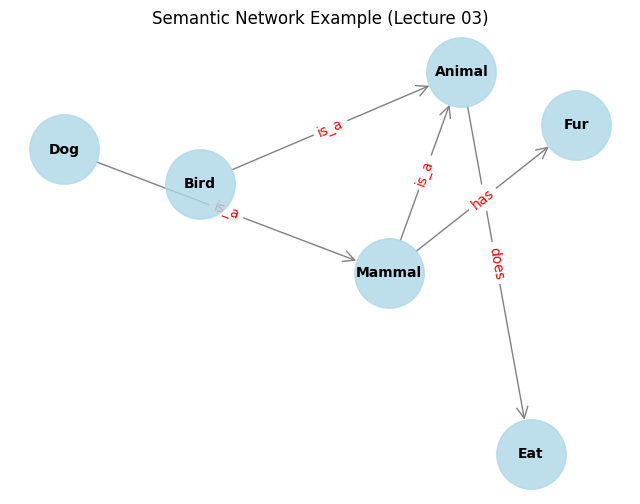

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create a directed graph
G = nx.DiGraph()

# 2. Add nodes (concepts)
nodes = ["Animal", "Eat", "Mammal", "Bird", "Fur", "Dog"]
G.add_nodes_from(nodes)

# 3. Add edges (relationships)
G.add_edge("Animal", "Eat", label="does")
G.add_edge("Mammal", "Animal", label="is_a")
G.add_edge("Bird", "Animal", label="is_a")
G.add_edge("Mammal", "Fur", label="has")
G.add_edge("Dog", "Mammal", label="is_a")

# 4. Draw the network
try:
    # 'spring_layout' gives a nice automatic layout
    pos = nx.spring_layout(G, seed=42, k=1.5)
    
    plt.figure(figsize=(8, 6))
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=2500, node_color="lightblue", alpha=0.8)
    
    # Draw labels (nodes)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, node_size=2500, arrowstyle="->", arrowsize=20, edge_color="gray")
    
    # Draw edge labels
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
    
    plt.title("Semantic Network Example (Lecture 03)")
    plt.axis('off') # Hide the axes
    plt.show()

except Exception as e:
    print("Could not draw plot. Make sure matplotlib and networkx are installed.")
    print("Error:", e)
    print("\nNetwork Edges:", G.edges(data=True))

### Exercise: Build Your Own Network

**Text:** "Belo Horizonte is a major city in Brazil, known for its architecture, cultural scene, and surrounding mountains. Landmarks include Praça da Liberdade, Mercado Central, and Pampulha. The Pampulha Lake area, designed by Oscar Niemeyer, is a city highlight."

**Task:** Identify the objects (nodes) and relationships (edges) from the text. Add them to a new `networkx` graph and try to visualize it.

Belo Horizonte Network Edges: [('Belo Horizonte', 'City', {'label': 'is_a'}), ('Belo Horizonte', 'Brazil', {'label': 'located_in'}), ('Belo Horizonte', 'Cultural Scene', {'label': 'famous_for'}), ('Praça da Liberdade', 'Belo Horizonte', {'label': 'located_in'}), ('Mercado Central', 'Belo Horizonte', {'label': 'located_in'}), ('Pampulha', 'Belo Horizonte', {'label': 'located_in'}), ('Pampulha Lake', 'Pampulha', {'label': 'part_of'}), ('Pampulha Complex', 'Pampulha', {'label': 'is_in'})]


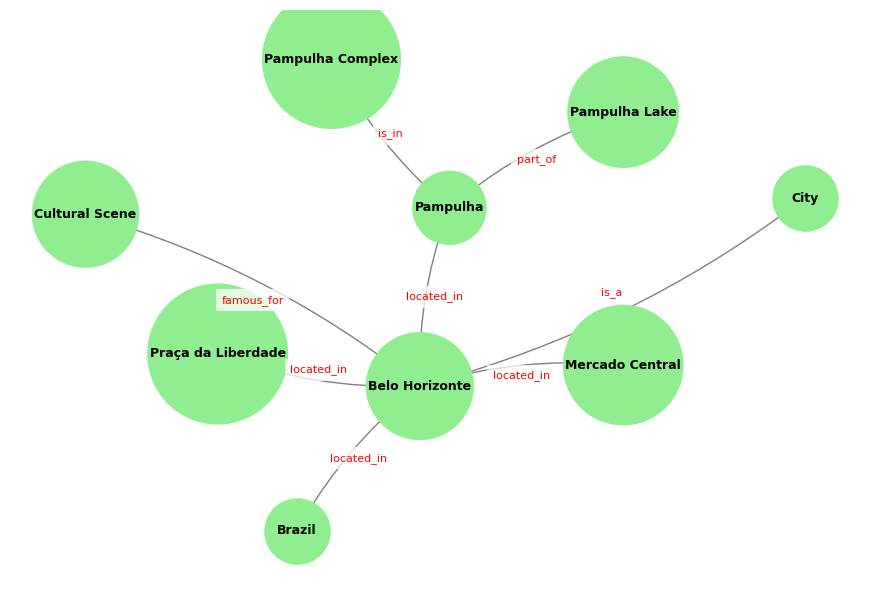

In [18]:
# Solution space for the exercise (Belo Horizonte)
G_bh = nx.DiGraph()

# Example relationships:
G_bh.add_edge("Belo Horizonte", "City", label="is_a")
G_bh.add_edge("Belo Horizonte", "Brazil", label="located_in")
G_bh.add_edge("Praça da Liberdade", "Belo Horizonte", label="located_in")
G_bh.add_edge("Mercado Central", "Belo Horizonte", label="located_in")
G_bh.add_edge("Pampulha", "Belo Horizonte", label="located_in")
G_bh.add_edge("Pampulha Lake", "Pampulha", label="part_of")
G_bh.add_edge("Pampulha Complex", "Pampulha", label="is_in")
G_bh.add_edge("Belo Horizonte", "Cultural Scene", label="famous_for")

print("Belo Horizonte Network Edges:", G_bh.edges(data=True))

# Optional: visualize the example
import matplotlib.pyplot as plt
def compute_layout(graph, seed=42, k=1.5, iterations=200):
    """Compute a spring layout with stronger repulsion and more iterations."""
    return nx.spring_layout(graph, seed=seed, k=k, iterations=iterations)

def enforce_min_distance(positions, min_dist=0.6, iterations=100, step=0.05):
    """Post-process 'positions' (dict node -> (x,y)) so every pair of nodes"""
    nodes = list(positions.keys())
    for _ in range(iterations):
        moved = False
        for i, a in enumerate(nodes):
            ax, ay = positions[a]
            dx, dy = 0.0, 0.0
            for j, b in enumerate(nodes):
                if i == j:
                    continue
                bx, by = positions[b]
                vx, vy = ax - bx, ay - by
                dist = (vx*vx + vy*vy) ** 0.5
                if dist < 1e-6:
                    vx, vy = (0.01, 0.01)
                    dist = (vx*vx + vy*vy) ** 0.5
                if dist < min_dist:
                    # push a away from b proportionally to the shortfall
                    push = (min_dist - dist) / dist * step
                    dx += vx * push
                    dy += vy * push
            if dx != 0.0 or dy != 0.0:
                positions[a] = (ax + dx, ay + dy)
                moved = True
        if not moved:
            break
    return positions

def draw_graph_with_labels(graph, positions):
    """Draw edges, nodes, node labels (inside circular bboxes) and edge labels with"""
    plt.figure(figsize=(9,6))
    nx.draw_networkx_edges(graph, positions, arrowstyle='->', arrowsize=12, edge_color='gray', connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_nodes(graph, positions, node_size=2200, node_color='lightgreen')
    labels = {n: n for n in graph.nodes()}
    nx.draw_networkx_labels(graph, positions, labels=labels, font_size=9, font_weight='bold', font_color='black', bbox=dict(boxstyle='circle,pad=0.2', facecolor='lightgreen', edgecolor='none'))
    # draw edge labels with semi-transparent background for readability
    edge_labels = nx.get_edge_attributes(graph, 'label')
    for (n1, n2), lbl in edge_labels.items():
        x1, y1 = positions[n1]
        x2, y2 = positions[n2]
        xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
        plt.text(xm, ym, lbl, fontsize=8, color='red', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'), horizontalalignment='center', verticalalignment='center')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Compute layout and apply minimum-distance relaxation (min_dist default: 0.6)
pos = compute_layout(G_bh, seed=42, k=1.5, iterations=200)
pos = enforce_min_distance(pos, min_dist=0.6, iterations=100, step=0.05)
# Finally draw using the cleaned positions
draw_graph_with_labels(G_bh, pos)

## 3. Frames

Frames are structured knowledge templates similar to objects in programming. A frame models a concept with **slots** (attributes) and **values**.

*(A frame diagram might show a box labeled 'Dog' with slots like `is_a: Mammal`, `color: default brown`, `legs: 4`.)*

Key features of Frames:

- **Slots:** Attributes of the concept (e.g., `Name`, `Breed`, `Fur`).
- **Values:** The data inside a slot. This can be:
  - A fixed value (e.g., `Name: "Rex"`)
  - A **default** value (e.g., `Breed: "Mongrel"`)
  - A range or type (e.g., `Sex: "Male or Female"`)
- **Inheritance:** A frame can be an instance of a class (e.g., "Rex" *is_a* "Dog") or a subclass of another (e.g., "Dog" *is_a* "Mammal"). Inheritance provides default slot values.
- **Demons:** Procedures attached to slots that can compute or update slot values on demand (e.g., computing `Area` from `Width` and `Height`).

### Code Example: Frames as Dictionaries

We can easily represent frames and instances as Python dictionaries.

In [22]:
# Class-based Frame example (English)
from typing import Any, Dict, Optional

class Frame:
    """A simple Frame class representing a concept with slots and defaults."""
    def __init__(self, name: str, is_a: Optional[str] = None, slots: Optional[Dict[str, Any]] = None):
        self.name = name
        self.is_a = is_a
        self.slots = slots or {}  # slot definitions or default values

    def instance(self, **values) -> 'Instance':
        "Return an Instance of this frame, filling slot values (falling back to defaults)."
        merged = dict(self.slots)  # defaults from the frame
        merged.update(values)
        return Instance(self.name, merged)

    def __repr__(self):
        return f"Frame(name={self.name!r}, is_a={self.is_a!r}, slots={self.slots!r})"

class Instance:
    def __init__(self, class_name: str, slots: Dict[str, Any]):
        self.class_name = class_name
        self.slots = slots

    def __repr__(self):
        return f"Instance(class={self.class_name!r}, slots={self.slots!r})"

# Define a generic 'Dog' frame
dog_frame = Frame('Dog', is_a='Mammal', slots={'Name': None, 'Breed': 'Mongrel', 'Fur': 'Long', 'Sex': ['Male', 'Female']})

# Create an instance using the frame
rex = dog_frame.instance(Name='Rex', Breed='German Shepherd', Sex='Male')

print('--- Generic Frame: Dog ---')
print(dog_frame)
print('--- Instance: Rex ---')
print(rex)

--- Generic Frame: Dog ---
Frame(name='Dog', is_a='Mammal', slots={'Name': None, 'Breed': 'Mongrel', 'Fur': 'Long', 'Sex': ['Male', 'Female']})
--- Instance: Rex ---
Instance(class='Dog', slots={'Name': 'Rex', 'Breed': 'German Shepherd', 'Fur': 'Long', 'Sex': 'Male'})


### Exercise: Model Rules as Frames

**Task:** Model the following decision rules using a Frame-like structure. Represent a `Car` class and possible instances. Implement a small function that recommends a car based on family size, usage, and budget.

Rules:
- If family_size = many, then car_size = large.
- If usage = leisure AND car_size = small AND budget = medium, then car = Corsa.
- If usage = leisure AND car_size = large AND budget = large, then car = Captiva.

In [23]:
# Class-based solution for 'Car' frames and a simple recommender
from typing import Dict, Any

class CarFrame:
    def __init__(self, name: str, slots: Dict[str, Any]):
        self.name = name
        self.slots = slots  # descriptive slots / defaults
    def matches(self, candidate: Dict[str, Any]) -> bool:
        "Return True if candidate properties match this frame's slots (loose match)."
        for k, v in self.slots.items():
            if k not in candidate:
                return False
            # allow equal or membership if slot is a list
            if isinstance(v, list):
                if candidate[k] not in v:
                    return False
            else:
                if candidate[k] != v:
                    return False
        return True
    def __repr__(self):
        return f"CarFrame(name={self.name!r}, slots={self.slots!r})"

# Define frames for Corsa and Captiva
corsa = CarFrame('Corsa', {'car_size': 'small', 'usage': 'leisure', 'budget': 'medium'})
captiva = CarFrame('Captiva', {'car_size': 'large', 'usage': 'leisure', 'budget': 'large'})

# A small helper to decide car size from family size
def decide_car_size(family_size: str) -> str:
    if family_size == 'many':
        return 'large'
    return 'small'

# Recommender using the frames
def recommend_car(family_size: str, usage: str, budget: str):
    car_size = decide_car_size(family_size)
    candidate = {'car_size': car_size, 'usage': usage, 'budget': budget}
    for frame in (corsa, captiva):
        if frame.matches(candidate):
            return frame.name
    return 'No recommendation (rule base did not match)'

# Examples
print(recommend_car('many', 'leisure', 'large'))  # Expect 'Captiva'
print(recommend_car('small', 'leisure', 'medium'))  # Expect 'Corsa'
print(recommend_car('small', 'work', 'medium'))  # No match

Captiva
Corsa
No recommendation (rule base did not match)


## 4. Scripts

While Frames represent *objects*, **Scripts** represent stereotypical *event sequences*. Think of them as the script for a play or movie.

Scripts help an AI understand and predict sequences of actions in common situations (e.g., "going to a restaurant", "visiting a doctor").

A Script has key elements:

- **Roles:** The people involved (e.g., `Customer`, `Waiter`).
- **Objects:** Relevant items (e.g., `Tables`, `Menu`, `Money`).
- **Entry conditions:** What must be true for the script to start (e.g., `Customer is hungry`, `Customer has money`).
- **Scenes:** The sequence of events (e.g., `Scene 1: Enter`, `Scene 2: Order`).
- **Outcomes:** What is true after the script finishes (e.g., `Customer is not hungry`, `Customer has less money`).

### Code Example: Restaurant Script as a Dictionary

In [4]:
# Structured 'Script' example using inheritance
from dataclasses import dataclass, field
from typing import List, Dict
import json


@dataclass
class Scene:
    name: str
    actions: List[str] = field(default_factory=list)


@dataclass
class Script:
    name: str
    roles: List[str] = field(default_factory=list)
    objects: List[str] = field(default_factory=list)
    entry_conditions: List[str] = field(default_factory=list)
    scenes: List[Scene] = field(default_factory=list)
    outcomes: List[str] = field(default_factory=list)

    def to_dict(self) -> Dict:
        return {
            'name': self.name,
            'roles': self.roles,
            'objects': self.objects,
            'entry_conditions': self.entry_conditions,
            'scenes': {s.name: s.actions for s in self.scenes},
            'outcomes': self.outcomes,
        }


class RestaurantScript(Script):
    def __init__(self):
        super().__init__(
            name='Restaurant Script',
            roles=['Customer', 'Waiter', 'Kitchen'],
            objects=['Tables', 'Chairs', 'Menu', 'Meal', 'Money', 'Tip'],
            entry_conditions=['Customer is hungry', 'Customer has money'],
            scenes=[
                Scene('Scene 1: Enter', ['Park the car', 'Enter the Restaurant', 'Wait for a Table (or Go to the Table)', 'Read the Menu']),
                Scene('Scene 2: Order', ['Call the Waiter', 'Order the Meal', 'Waiter delivers order to Kitchen']),
                Scene('Scene 3: Eat', ['Kitchen prepares the Meal', 'Waiter brings the Meal', 'Customer eats the Meal']),
                Scene('Scene 4: Leave', ['Ask for the bill', 'Pay for the Meal', 'Give a Tip (optional)', 'Leave the Restaurant']),
            ],
            outcomes=['Customer is not hungry', 'Customer has less money', 'Restaurant has more money'],
        )


restaurant = RestaurantScript()
print(restaurant.to_dict())


{'name': 'Restaurant Script', 'roles': ['Customer', 'Waiter', 'Kitchen'], 'objects': ['Tables', 'Chairs', 'Menu', 'Meal', 'Money', 'Tip'], 'entry_conditions': ['Customer is hungry', 'Customer has money'], 'scenes': {'Scene 1: Enter': ['Park the car', 'Enter the Restaurant', 'Wait for a Table (or Go to the Table)', 'Read the Menu'], 'Scene 2: Order': ['Call the Waiter', 'Order the Meal', 'Waiter delivers order to Kitchen'], 'Scene 3: Eat': ['Kitchen prepares the Meal', 'Waiter brings the Meal', 'Customer eats the Meal'], 'Scene 4: Leave': ['Ask for the bill', 'Pay for the Meal', 'Give a Tip (optional)', 'Leave the Restaurant']}, 'outcomes': ['Customer is not hungry', 'Customer has less money', 'Restaurant has more money']}


### Exercise: Build a Cinema Script

**Task:** Create a script for "Going to the cinema". Include a scene for buying popcorn and going to the restroom.

### Solution Example:

- **Roles:** `Viewer`, `Box Office Attendant`, `Concession Attendant`
- **Objects:** `Ticket`, `Popcorn`, `Movie`, `Restroom`
- **Entry Conditions:** `Viewer wants to see the movie`, `Viewer has money`
- **Scenes:** `Arrive at cinema`, `Buy ticket`, `Buy popcorn`, `Watch the movie` (may be interrupted), `Go to restroom`
- **Outcomes:** `Viewer watched the movie`, `Viewer has less money`

In [3]:
class CinemaScript(Script):
    def __init__(self):
        super().__init__(
            name='Cinema Script',
            roles=['Viewer', 'Box Office Attendant', 'Concession Attendant'],
            objects=['Ticket', 'Popcorn', 'Movie', 'Restroom'],
            entry_conditions=['Viewer wants to see the movie', 'Viewer has money'],
            scenes=[
                Scene('Arrive', ['Arrive at cinema', 'Find seat']),
                Scene('Buy Ticket', ['Queue at box office', 'Buy ticket']),
                Scene('Concessions', ['Buy popcorn', 'Buy drink']),
                Scene('Watch Movie', ['Watch the movie', 'May be interrupted']),
                Scene('Restroom', ['Go to restroom if needed']),
            ],
            outcomes=['Viewer watched the movie', 'Viewer has less money'],
        )


cinema = CinemaScript()
print(cinema.to_dict())


{'name': 'Cinema Script', 'roles': ['Viewer', 'Box Office Attendant', 'Concession Attendant'], 'objects': ['Ticket', 'Popcorn', 'Movie', 'Restroom'], 'entry_conditions': ['Viewer wants to see the movie', 'Viewer has money'], 'scenes': {'Arrive': ['Arrive at cinema', 'Find seat'], 'Buy Ticket': ['Queue at box office', 'Buy ticket'], 'Concessions': ['Buy popcorn', 'Buy drink'], 'Watch Movie': ['Watch the movie', 'May be interrupted'], 'Restroom': ['Go to restroom if needed']}, 'outcomes': ['Viewer watched the movie', 'Viewer has less money']}
